# Transformers
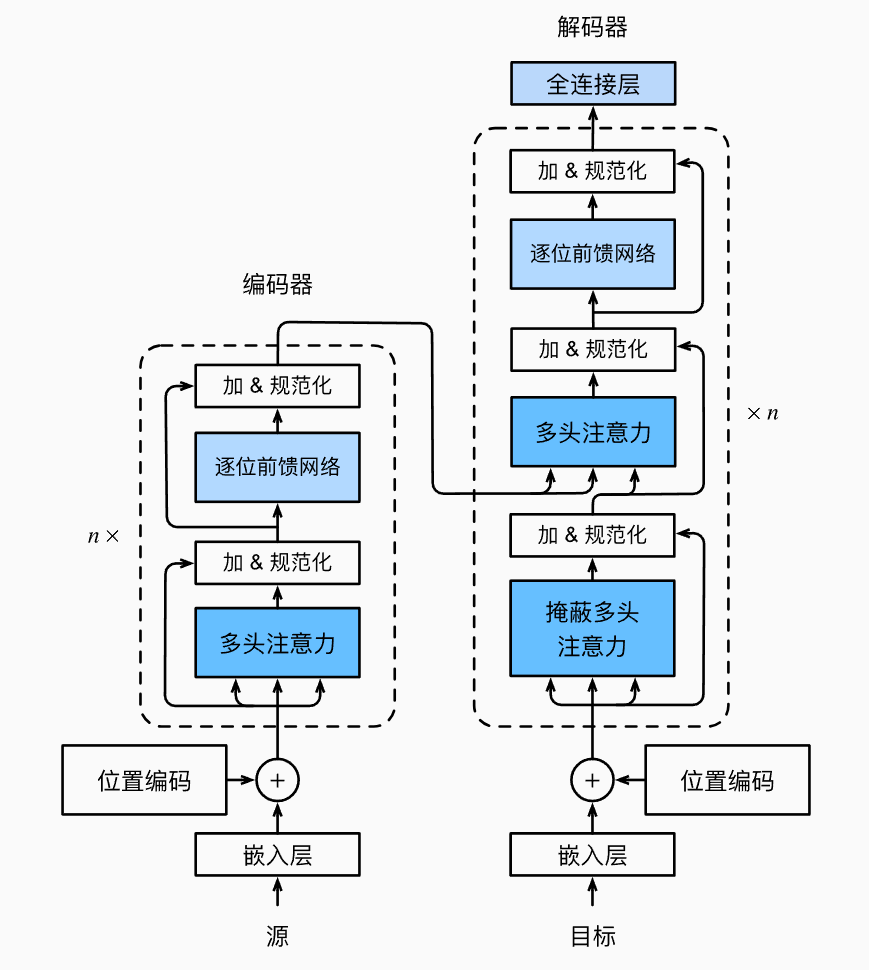
## 基于位置的前馈网络
回想一下自注意力的计算过程：$Attention(Q, K, V) = \text{softmax}(\frac{QK^T}{\sqrt{d_k}})V$，
抛开 Softmax 这个只用来算权重的操作不谈，自注意力的核心其实就是对 Value 矩阵进行加权求和，这本质上依然是一个高度线性的操作

如果没有 FFN，哪怕你堆叠了 100 层自注意力，整个模型依然非常扁平，缺乏拟合复杂非线性函数的能力

FFN 引入了非线性激活函数
$$FFN(x) = \max(0, xW_1 + b_1) W_2 + b_2$$
通过 ReLU（$\max(0, ...)$）的强非线性截断，模型终于拥有了极其强大的特征拟合能力，能够真正“读懂”语言中那些千回百转的逻辑

In [ ]:
import math
import pandas as pd
import torch
from torch import nn

class PositionWiseFFN(nn.Module):
    """基于位置的前馈网络"""
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs,
                 **kwargs):
        super(PositionWiseFFN, self).__init__(**kwargs)
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

## 残差连接
假设上一层的输出是 $X$（这代表着原始信息），当前经过了自注意力层或 FFN 层处理后，得到的结果是 $F(X)$

如果没有残差连接，下一层的输入就是 $F(X)$。如果这一层学歪了或者梯度消失了，信息就彻底断了

加入了残差连接后，输出变成了：
$$Y = X + F(X)$$

## LayerNorm
BatchNorm 是对同一个批次（Batch）内所有样本的同一个特征维度求均值和方差

LayerNorm 改变了归一化的方向：它不再跨样本计算，而是专门对当前这一个词的特征向量内部进行归一化
$$Y = \frac{X - \mu}{\sqrt{\sigma^2 + \epsilon}} \cdot \gamma + \beta$$

In [ ]:
class AddNorm(nn.Module):
    """残差连接后进行层归一化"""
    def __init__(self, normalized_shape, dropout, **kwargs):
        super(AddNorm, self).__init__(**kwargs)
        # 丢弃法，用于正则化，防止过拟合
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

## Encoder
编码器是由多个完全相同的编码器块堆叠而成的，之所以能够不断堆叠，核心原因在于每个编码器块的输入和输出维度是完全一致的

一个标准的编码器块主要由两个主要的子层构成，并且每个子层都伴随着一套标准的残差连接和层规范化

### 子层一：多头自注意力机制
当输入序列 $X$（形状为 [批量大小, 序列长度, 隐藏层维度 d_model]）进入编码器块时，首先遇到的就是多头自注意力层

查询（Query）、键（Key）和值（Value）全部来自同一个输入 $X$。模型通过三个不同的线性变换矩阵将 $X$ 映射成 $Q$、$K$ 和 $V$

模型并行地计算多个“头”的注意力权重。它计算序列中每个词元与其他所有词元的相似度（点积），借此来捕获句子内部的语法关联和上下文依赖

由于一个批次内的句子长度不同，我们会用特殊的 pad 词元将短句补齐，为了防止注意力机制关注到这些毫无意义的填充词元，编码器内部会使用一个掩码，将对应 pad 位置的注意力权重强制设为极小值，使其在 Softmax 后接近于零

### 残差连接与层规范化
自注意力层计算完毕后，并不会直接输出，而是要经过一个“Add & Norm”模块

Add（残差连接）：
将自注意力层的输入 $X$ 直接与自注意力层的输出相加

公式表达为：$X + \text{SelfAttention}(X)$

Norm（层规范化 Layer Normalization）：

随后，对相加的结果进行层规范化

公式表达为：$X_{\text{attention}} = \text{LayerNorm}(X + \text{SelfAttention}(X))$

### 子层二：基于位置的前馈网络
经过第一个 Add & Norm 后的输出 $X_{\text{attention}}$，接下来会被送入前馈网络

它是一个包含两个线性层（全连接层）的简单网络，中间通常夹着一个 ReLU 激活函数
$$\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2$$

### 残差连接与层规范化
最后，前馈网络的输出再次经过一模一样的“Add & Norm”处理
$X_{\text{out}} = \text{LayerNorm}(X_{\text{attention}} + \text{FFN}(X_{\text{attention}}))$